<a href="https://colab.research.google.com/github/artcoding93/Numerical-Recipe-Archive/blob/main/02_Bisection/bisection_method_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

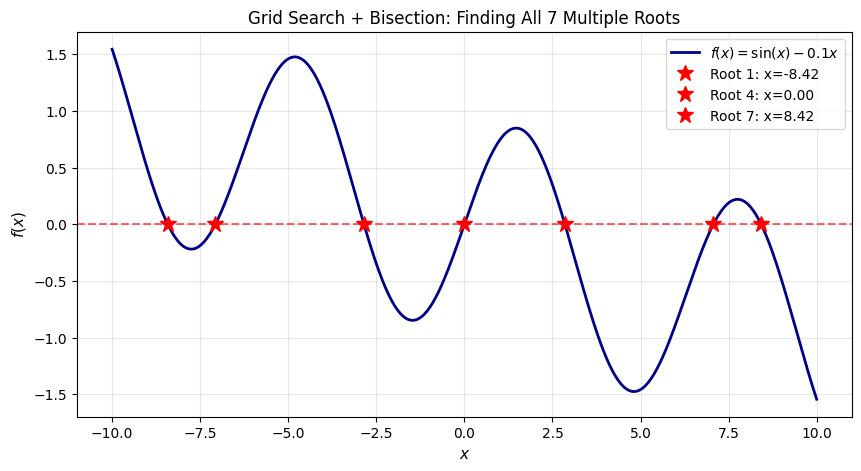

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 다중 해 비선형 방정식
def target_func(x):
    return np.sin(x) - 0.1 * x

# 2. 1단계 Grid Search + 2단계 Bisection 알고리즘
def find_root_intervals(func, start, end, num_subintervals=100):
    x_grid = np.linspace(start, end, num_subintervals)
    intervals = []
    for i in range(len(x_grid) - 1):
        if func(x_grid[i]) * func(x_grid[i+1]) < 0:
            intervals.append((x_grid[i], x_grid[i+1]))
    return intervals

def solve_all_roots(func, start, end, tol=1e-6):
    intervals = find_root_intervals(func, start, end)
    roots = []
    for a, b in intervals:
        for _ in range(100):
            c = (a + b) / 2.0
            f_c = func(c)
            if abs(f_c) < tol or (b - a) / 2.0 < tol:
                roots.append(c)
                break
            if func(a) * f_c < 0:
                b = c
            else:
                a = c
    return roots

# 해 도출
start_val, end_val = -10.0, 10.0
all_roots = solve_all_roots(target_func, start_val, end_val)

# ---------------------------------------------------------
# 3. f(x) 함수 그래프 및 7개 해(Multiple Roots) 위치 시각화
# ---------------------------------------------------------
x_vals = np.linspace(-10.0, 10.0, 500)
f_vals = target_func(x_vals)

plt.figure(figsize=(10, 5))
plt.plot(x_vals, f_vals, label=r'$f(x) = \sin(x) - 0.1x$', color='darkblue', lw=2)
plt.axhline(0, color='red', linestyle='--', alpha=0.6)

# 찾아낸 7개의 해(Roots)를 그래프 상에 별 모양으로 표기
for idx, r in enumerate(all_roots, 1):
    plt.plot(r, target_func(r), 'r*', markersize=12, label=f'Root {idx}: x={r:.2f}' if idx in [1, 4, 7] else "")

plt.title('Grid Search + Bisection: Finding All 7 Multiple Roots', fontsize=12)
plt.xlabel('$x$', fontsize=11)
plt.ylabel('$f(x)$', fontsize=11)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')
plt.show()